In [ ]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
filename='/content/drive/MyDrive/AI/data/output/out_sentiment.pickle'

In [ ]:
fp=open(filename,'rb')
litigi=pickle.load(fp)
fp.close()

In [ ]:
litigi

,author,author_flair_css_class,author_flair_text,body,can_gild,collapsed,collapsed_reason,controversiality,created_utc,distinguished,...,editable,submission_id,updated_utc,body_sha1,utc_datetime_str,nest_level,edited_on,body_preprocessed,sentiment,num_words
0,Trickyhere,None,None,Qualcosa da spaccare?,True,0.0,None,0.0,1502873647,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Qualcosa da spaccare?,neutral,3
1,panicClark,None,None,"Avevo quest'ideona dello sticky giornaliero ""A...",True,0.0,None,0.0,1502873820,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Avevo quest'ideona dello sticky giornaliero ""A...",neutral,18
2,MeccAnon,None,None,"Risposta USENET: ""non l'avete capita"" (cit.)\n...",True,0.0,None,0.0,1502874353,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Risposta USENET: ""non l'avete capita"" (cit.) ...",neutral,30
3,panicClark,None,None,[GENIO.](https://www.reddit.com/r/litigi/comme...,True,0.0,None,0.0,1502876399,moderator,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GENIO.,neutral,1
4,MeccAnon,None,None,&gt; nella sidebar trovate il suo manifesto or...,True,0.0,None,0.0,1502877513,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,&gt; nella sidebar trovate il suo manifesto or...,neutral,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362577,NaN,NaN,NaN,Temo di sì.\nNon ho mai voluto entrare su alcu...,NaN,NaN,NaN,NaN,1631023370,NaN,...,NaN,pja1kr,NaN,NaN,NaN,NaN,NaN,Temo di sì. Non ho mai voluto entrare su alcun...,negative,37
362578,NaN,NaN,NaN,no questo mai sentito prima,NaN,NaN,NaN,NaN,1630997742,NaN,...,NaN,pja1kr,NaN,NaN,NaN,NaN,NaN,no questo mai sentito prima,negative,5
362579,NaN,NaN,NaN,Benvenuto su r/litigi il sub di riferimento pe...,NaN,NaN,NaN,NaN,1631024111,NaN,...,NaN,pja1kr,NaN,NaN,NaN,NaN,NaN,Benvenuto su r/litigi il sub di riferimento pe...,positive,15
362580,NaN,NaN,NaN,> e tuttora non ci sono.\n\nho una brutta not...,NaN,NaN,NaN,NaN,1631435339,NaN,...,NaN,pja1kr,NaN,NaN,NaN,NaN,NaN,ho una brutta notizia per te,negative,6


In [ ]:
litigi[['body_preprocessed','sentiment','num_words']]

,body_preprocessed,sentiment,num_words
0,Qualcosa da spaccare?,neutral,3
1,"Avevo quest'ideona dello sticky giornaliero ""A...",neutral,18
2,"Risposta USENET: ""non l'avete capita"" (cit.) ...",neutral,30
3,GENIO.,neutral,1
4,&gt; nella sidebar trovate il suo manifesto or...,neutral,46
...,...,...,...
362577,Temo di sì. Non ho mai voluto entrare su alcun...,negative,37
362578,no questo mai sentito prima,negative,5
362579,Benvenuto su r/litigi il sub di riferimento pe...,positive,15
362580,ho una brutta notizia per te,negative,6


In [ ]:
df_pivot = pd.pivot_table(
    litigi,
    index='author',
    columns="sentiment",
    aggfunc='size'
)

In [ ]:
df_pivot=df_pivot.fillna(0)
df_pivot=df_pivot.sort_values('positive',ascending=False)
df_pivot['positive_ratio']=df_pivot['positive']/(df_pivot['negative']+df_pivot['neutral'])
df_pivot['p/n']=df_pivot['positive']/(df_pivot['negative'])

In [ ]:
df_pivot

sentiment,negative,neutral,positive,positive_ratio,p/n
author,,,,,
[deleted],7872.0,62134.0,5005.0,0.071494,0.635798
SpiegoLeDiscussioni,3903.0,9342.0,3361.0,0.253756,0.861132
sda_express,2503.0,4880.0,1316.0,0.178247,0.525769
Tom_Hadar,1193.0,3727.0,1301.0,0.264431,1.090528
RedAliena,1085.0,1056.0,1157.0,0.540402,1.066359
...,...,...,...,...,...
finlaido,0.0,1.0,0.0,0.000000,NaN
flugelturer,0.0,1.0,0.0,0.000000,NaN
fluicpana,0.0,1.0,0.0,0.000000,NaN


In [ ]:
litigi[(litigi['num_words']==1) & (litigi['body_preprocessed']!='[deleted]')][['body_preprocessed']]

,body_preprocessed
3,GENIO.
31,**ditomedio**
74,Contamici!
85,Dica
110,curati
...,...
362537,Marylin?
362545,r/profilobassochecksout
362568,superovvio
362574,eh.


In [ ]:
df_pivot.to_csv('/content/drive/MyDrive/AI/data/output/litigi_sentiment.csv')

<AxesSubplot:>

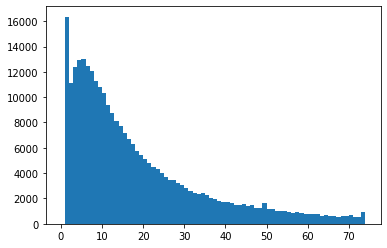

In [ ]:
litigi[(litigi['body_preprocessed']!='[deleted]') &(litigi['body_preprocessed']!='[removed]') ]['num_words'].hist(bins=range(75),grid=False)

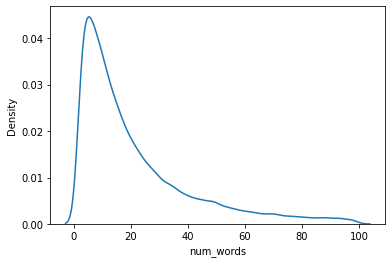

In [ ]:
sns.kdeplot(litigi[ (litigi['num_words']<100) &(litigi['num_words']>1) ]['num_words'])
plt.show()

In [ ]:
author_list=['tommyrugby','sda_express','SpiegoLeDiscussioni','PHEELZ']

In [ ]:
df_filtered = litigi[litigi['author'].isin(author_list)]

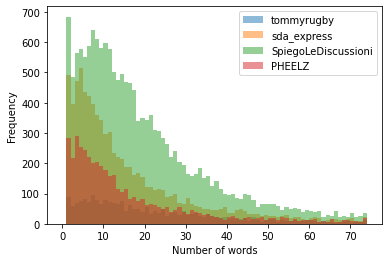

In [ ]:
for author in author_list:
    plt.hist(df_filtered[df_filtered['author'] == author]['num_words'], alpha=0.5, label=author,bins=range(75))
plt.legend(loc='upper right')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.show()

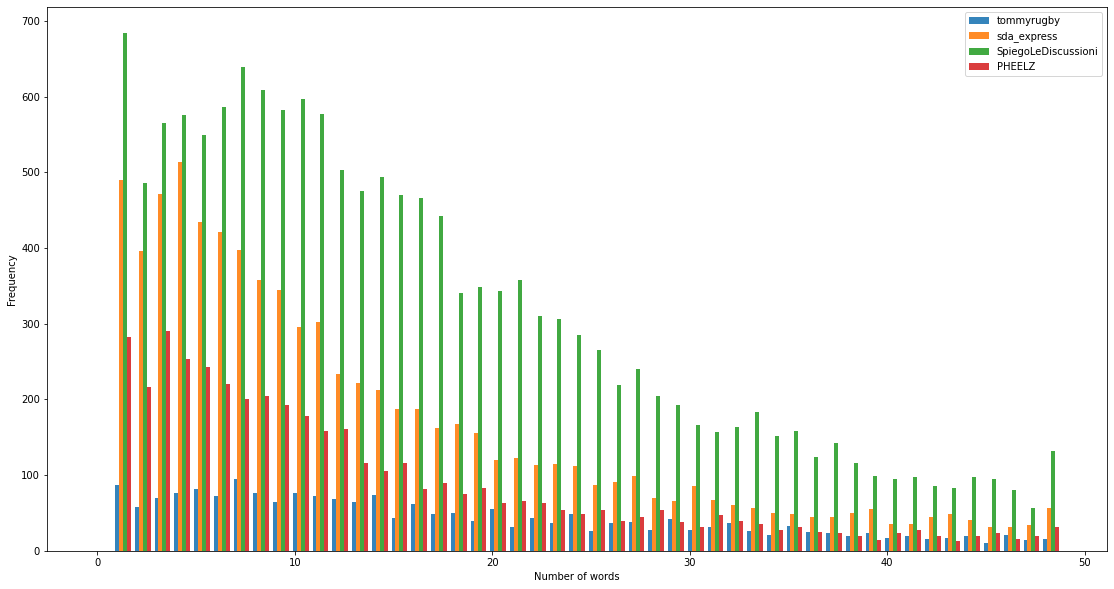

In [ ]:

histograms = []
for author in author_list:
    author_hist, _ = np.histogram(df_filtered[df_filtered['author'] == author]['num_words'],bins=range(50))
    histograms.append(author_hist)

# Plot histograms side by side
plt.figure(figsize=(19, 10))
width = 0.2
x = np.arange(len(histograms[0]))

for i, author_hist in enumerate(histograms):
    plt.bar(x + i*width, author_hist, width=width, alpha=0.9, label=author_list[i])

plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()


In [ ]:
date=pd.to_datetime(litigi['created_utc'], unit='s').dt.date
date

0         2017-08-16
1         2017-08-16
2         2017-08-16
3         2017-08-16
4         2017-08-16
             ...    
362577    2021-09-07
362578    2021-09-07
362579    2021-09-07
362580    2021-09-12
362581    2021-09-12
Name: created_utc, Length: 362582, dtype: object

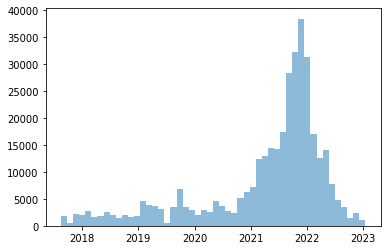

In [ ]:
plt.hist(date,bins=50,alpha=0.5)

plt.show()

In [ ]:
time=pd.to_datetime(litigi['created_utc'], unit='s').dt.hour
time

0          8
1          8
2          9
3          9
4          9
          ..
362577    14
362578     6
362579    14
362580     8
362581     9
Name: created_utc, Length: 362582, dtype: int64

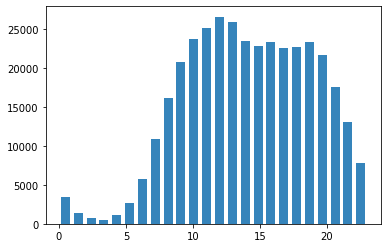

In [ ]:
plt.hist(time,alpha=0.9,rwidth=0.7,bins=24)

plt.show()

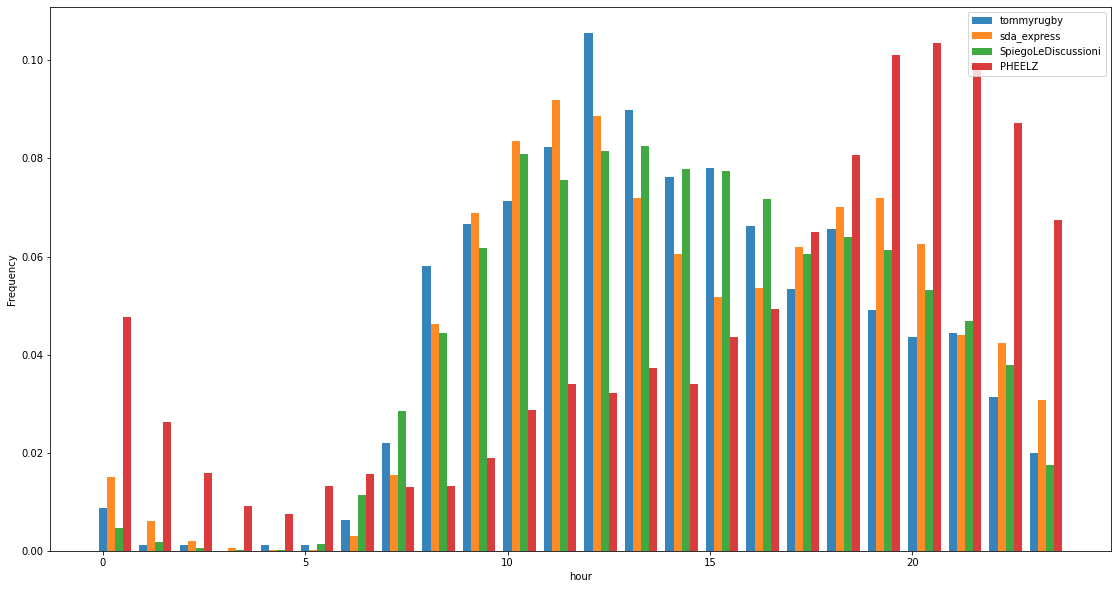

In [ ]:
histograms = []
for author in author_list:
    author_hist, _ = np.histogram(pd.to_datetime(df_filtered[df_filtered['author'] == author]['created_utc'], unit='s').dt.hour,bins=24,density=True)
    histograms.append(author_hist)

# Plot histograms side by side
plt.figure(figsize=(19, 10))
width = 0.2
x = np.arange(len(histograms[0]))

for i, author_hist in enumerate(histograms):
    plt.bar(x + i*width, author_hist, width=width, alpha=0.9, label=author_list[i])

plt.xlabel('hour')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

In [ ]:
df_filtered = litigi[litigi['author'].isin(author_list)]

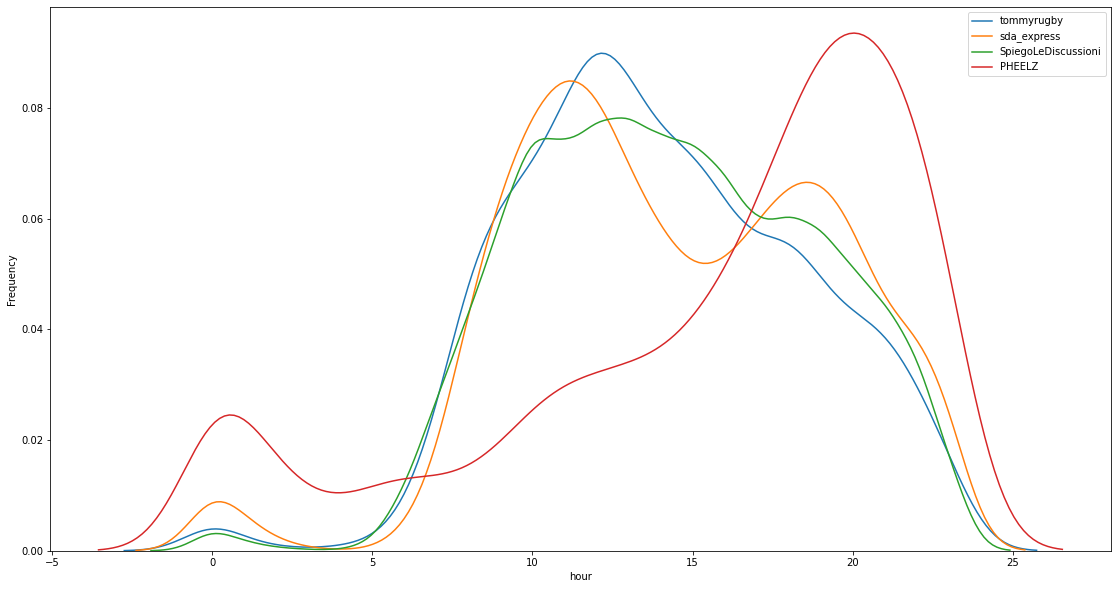

In [ ]:
plt.figure(figsize=(19, 10))

for author in author_list:
    sns.kdeplot(pd.to_datetime(df_filtered[df_filtered['author'] == author]['created_utc'], unit='s').dt.hour,label=author)
    #histograms.append(author_hist)

plt.xlabel('hour')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

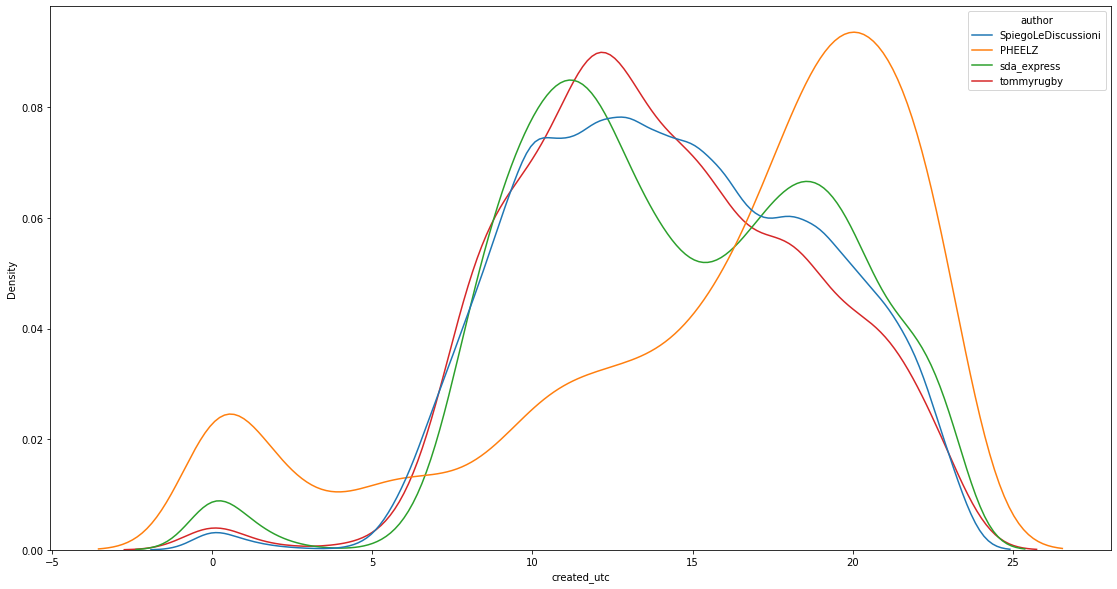

In [ ]:
plt.figure(figsize=(19, 10))

sns.kdeplot(data=df_filtered,x=pd.to_datetime(df_filtered['created_utc'], unit='s').dt.hour,label=author,hue='author', common_norm=False)
plt.show()